# 1) Load Data and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, f1_score

import cupy as cp
import cudf
from cuml.preprocessing import StandardScaler
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.metrics import accuracy_score

import xgboost as xgb

In [2]:
df = pd.read_csv("sample_to_run_info.csv")

/tmp/ipykernel_947/2515147133.py:1: DtypeWarning: Columns (22,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sample_to_run_info.csv")


In [3]:
abundance = pd.read_csv('species_abundance.csv')

# 2) Exploratory Data Analysis & Cleaning

### Work with the Sample to Run Info (df)

In [4]:
# Get rid of all features that have more than 50% of their data missing
thresh = int(len(df) * 0.5)
df = df.dropna(axis=1, thresh=thresh)

In [5]:
# Sneak peek at data
df.head()

,project_id,sample_name,original_sample_description,run_id,sample_id,second_sample_id,experiment_type,nr_reads_sequenced,instrument_model,disease,phenotype,more,country,collection_date,longitude,latitude
0,PRJDB3418,NaN,APr10S00,DRR028772,DRS020620,SAMD00024580,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
1,PRJDB3418,NaN,APr14S00,DRR028773,DRS020607,SAMD00024581,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
2,PRJDB3418,NaN,APr15S00,DRR028774,DRS020582,SAMD00024582,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
3,PRJDB3418,NaN,APr21S00,DRR028775,DRS020613,SAMD00024583,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
4,PRJDB3418,NaN,APr24S00,DRR028776,DRS020600,SAMD00024584,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN


In [6]:
# Removed what is determined to be unnecessary
df = df.drop(['more', 'collection_date', 'longitude', 'latitude', 'sample_name', 'original_sample_description', 'sample_id', 'second_sample_id', 'disease'], axis=1)

In [7]:
df['phenotype'].value_counts()

,count
phenotype,
Healthy,48241
Colorectal Neoplasms,5543
Crohn Disease,3516
COVID-19,2911
Parkinson Disease,2169
...,...
Colonic Polyps,5
Urolithiasis,5
Dry Eye Syndromes,4


In [8]:
# The phenotypes we will be keeping
keep_phenos = [
    "Healthy",
    "Crohn Disease",
    "Colitis, Ulcerative",
]

df = df[df["phenotype"].isin(keep_phenos)].copy()

In [9]:
# A stricter filter to keep only the projects which are mainly associated with these phenotypes
target_phenotypes = ["Crohn Disease", "Colitis, Ulcerative"]

project_ids = (
    df[df["phenotype"].isin(target_phenotypes)]["project_id"]
    .unique()
)

df = df[df["project_id"].isin(project_ids)].copy()

print(f"Projects with at least one Crohn Disease or Ulcerative Colitis sample: {len(project_ids)}")
print(df["phenotype"].value_counts())

Projects with at least one Crohn Disease or Ulcerative Colitis sample: 46
phenotype
Crohn Disease          3516
Healthy                2099
Colitis, Ulcerative    1863
Name: count, dtype: int64


In [10]:
df['country'].value_counts()

,count
country,
United States of America,3698
China,970
Canada,666
Sweden,637
South Korea,263
Japan,196
Russia,168
Germany,167
India,101


In [11]:
df['experiment_type'].value_counts()

# amplicon is a piece of DNA or RNA that is
# the source and/or product of natural or artificial
# amplification or replication, commonly produced via PCR (Polymerase Chain Reaction)

# Metagenomics is the study of genetic material directly extracted from environmental
# samples—such as soil, water, or the human gut—without culturing individual microorganisms.

# There is a decent split between both methods, so likely very little bias

,count
experiment_type,
AMPLICON,4444
Metagenomics,3034


In [12]:
# Check whether certain diseases are overrepresented on a given platform for instrument_model.
# As per the counts table, non of them are suspiciously different as there were many other diseases involved
ct_counts = pd.crosstab(df['phenotype'], df['instrument_model'])
print(ct_counts)

instrument_model     454 GS  454 GS FLX Titanium  AB 5500 Genetic Analyzer  \
phenotype                                                                    
Colitis, Ulcerative      11                   60                         0   
Crohn Disease            10                   99                        15   
Healthy                   9                   97                         0   

instrument_model     AB SOLiD 4 System  HiSeq X Ten  Illumina HiSeq 2000  \
phenotype                                                                  
Colitis, Ulcerative                  0           25                  709   
Crohn Disease                        7           41                 1203   
Healthy                              0           15                 1105   

instrument_model     Illumina HiSeq 2500  Illumina HiSeq 4000  \
phenotype                                                       
Colitis, Ulcerative                  612                    0   
Crohn Disease                    

### Work with the Species Abundance (abundance)

In [13]:
abundance.head()

,id,loaded_uid,ncbi_taxon_id,taxon_rank_level,relative_abundance,accession_id
0,1,81104,-1,genus,1.95190,DRR358335
1,2,81104,544,genus,1.07457,DRR358335
2,3,81104,561,genus,0.84957,DRR358335
3,4,81104,570,genus,0.06218,DRR358335
4,5,81104,816,genus,23.29699,DRR358335


In [14]:
abundance['taxon_rank_level'].value_counts()

,count
taxon_rank_level,
genus,2780064
species,2761207


In [15]:
# Keep only species level because it is more specific than genus, allowing us to
# better pinpoint bacteria types and reasoning
abund_genus = abundance[abundance["taxon_rank_level"] == "species"].copy()

# Drop rows with ncbi_taxon_id = -1 (unassigned/other)
abund_genus = abund_genus[abund_genus["ncbi_taxon_id"] != -1].copy()

In [16]:
# We take bacteria names and make them columns, and if they exist, their values
# are relative abundances

# Pivot: run_id x ncbi_taxon_id, values = relative_abundance
abund_wide = (
    abund_genus
    .pivot_table(index="accession_id",      # this matches run_id in df
                 columns="ncbi_taxon_id",
                 values="relative_abundance",
                 aggfunc="sum",
                 fill_value=0.0)
    .reset_index()
)

# Make column names nicer (e.g., taxon_544, taxon_561, ...)
abund_wide.columns = [
    "run_id" if c == "accession_id" else f"taxon_{int(c)}"
    for c in abund_wide.columns
]

### Merge the data

In [17]:
merged = df.merge(abund_wide, on="run_id", how="inner")

In [18]:
merged.head()

,project_id,run_id,experiment_type,nr_reads_sequenced,instrument_model,phenotype,country,taxon_9,taxon_17,taxon_69,...,taxon_2968459,taxon_2968968,taxon_2969304,taxon_2972461,taxon_2972466,taxon_2972769,taxon_2974552,taxon_2974597,taxon_2975484,taxon_2981769
0,PRJEB76677,ERR13295986,Metagenomics,61317544.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
1,PRJEB76677,ERR13295987,Metagenomics,44948398.0,Illumina HiSeq 2000,Healthy,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.55599
2,PRJEB76677,ERR13295988,Metagenomics,7314392.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
3,PRJEB76677,ERR13295989,Metagenomics,48624378.0,Illumina HiSeq 2000,Healthy,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.45498
4,PRJEB76677,ERR13295990,Metagenomics,61732518.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01691


In [19]:
# The following features, after EDA, aren't relevant
merged = merged.drop(['experiment_type', 'instrument_model', 'country'], axis=1)

# 3) Feature Engineering, Data Splitting, & Label Preparation

In this section we:
1. Create labels for the three phenotypes (Healthy=0, Crohn=1, UC=2)
2. **First split**: Create a train/test split on ALL taxa for L1 feature selection
3. Extract selected features via LASSO

This split approach ensures:
- Feature selection is not biased by the test set used later
- All downstream models use the same clean evaluation split

In [20]:
keep_phenos = ["Healthy", "Crohn Disease", "Colitis, Ulcerative"]
df3 = merged[merged["phenotype"].isin(keep_phenos)].copy()

# We label them to 0, 1, and 2 for multiclass labelling
label_map = {
    "Healthy": 0,
    "Crohn Disease": 1,
    "Colitis, Ulcerative": 2,
}
df3["label"] = df3["phenotype"].map(label_map)

taxon_cols = [c for c in df3.columns if c.startswith("taxon_")]

gdf = cudf.from_pandas(df3[["label"] + taxon_cols])

# The data we will actually train on
X = gdf[taxon_cols]
y = gdf["label"]


In [21]:
df_train, df_test = train_test_split(
    df3, test_size=0.2, stratify=df3["label"], random_state=42
)

X_train_pd      = df_train[taxon_cols].values
X_test_pd       = df_test[taxon_cols].values
y_train_pd      = df_train["label"].values
y_test_pd       = df_test["label"].values
phenotype_train = df_train["phenotype"].values
phenotype_test  = df_test["phenotype"].values

# Make it so GPU can work with it
X_train = cudf.DataFrame(df_train, columns=taxon_cols)
X_test  = cudf.DataFrame(X_test_pd,  columns=taxon_cols)
y_train = cudf.Series(y_train_pd)
y_test  = cudf.Series(y_test_pd)

# 4) GPU L1 Logistic Regression (Feature Selection via LASSO)

Train an L1-regularized logistic regression on all taxa to select a sparse feature set. The union of non-zero coefficients across classes becomes our feature set.

In [22]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

clf = cuLogisticRegression(
    penalty="l1",
    C=0.1,                 # tune for sparsity
    l1_ratio=None,         # pure L1
    fit_intercept=True,
    class_weight="balanced",
    max_iter=5000,
    solver="qn",           # cuML solver
    verbose=0
)

In [23]:
clf.fit(X_train_scaled, y_train)

LogisticRegression()

In [24]:
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("GPU multinomial L1-logreg accuracy:", float(acc))

GPU multinomial L1-logreg accuracy: 0.6795774647887324


In [25]:
# coef_ is a cuDF DataFrame: shape (n_classes, n_features)
coefs_cudf = clf.coef_

# Convert to pandas / NumPy
coefs = coefs_cudf.to_pandas().to_numpy()   # (n_classes, n_features)

# classes_ is already a NumPy array (e.g., array([0, 1, 2]))
classes = clf.classes_

# Union of non-zero features across classes
nz_any = (coefs != 0).any(axis=0)
selected_taxa_union = np.array(taxon_cols)[nz_any]

print("Total taxa:", len(taxon_cols))
print("Selected by LASSO (any class):", len(selected_taxa_union))

selected_df = pd.DataFrame({
    "taxon": selected_taxa_union,
    "coef_l1_sum": np.abs(coefs[:, nz_any]).sum(axis=0)
}).sort_values("coef_l1_sum", ascending=False)

print(selected_df.head(30))


Total taxa: 2893
Selected by LASSO (any class): 662
             taxon  coef_l1_sum
495  taxon_2093857     0.443362
510  taxon_2292190     0.408046
355  taxon_1411144     0.388547
653  taxon_2929491     0.361545
497  taxon_2126740     0.357193
513  taxon_2292205     0.355758
269   taxon_371601     0.353144
120    taxon_33039     0.342653
496  taxon_2108523     0.336857
97     taxon_28116     0.331635
229   taxon_208479     0.327949
517  taxon_2292271     0.324972
439  taxon_1898207     0.304584
56      taxon_1531     0.304005
617  taxon_2787149     0.299813
280   taxon_437897     0.291875
287   taxon_487175     0.287169
99     taxon_28118     0.278168
23       taxon_820     0.272796
380  taxon_1632013     0.272780
230   taxon_209880     0.267853
164    taxon_54005     0.263871
537  taxon_2485925     0.261212
308   taxon_626940     0.259259
578  taxon_2763017     0.257446
536  taxon_2479840     0.255444
332  taxon_1034346     0.253551
605  taxon_2763675     0.250700
500  taxon_2259133  

In [26]:
# We keep all the features which haven't been minimized to ~0
X_train_lasso = pd.DataFrame(X_train_pd, columns=taxon_cols)[selected_taxa_union]
X_test_lasso  = pd.DataFrame(X_test_pd,  columns=taxon_cols)[selected_taxa_union]

full_lasso = pd.concat(
    [df3.drop(columns=taxon_cols), df3[selected_taxa_union]],
    axis=1
)

In [27]:
full_lasso.head()

,project_id,run_id,nr_reads_sequenced,phenotype,label,taxon_201,taxon_316,taxon_329,taxon_347,taxon_470,...,taxon_2924040,taxon_2929491,taxon_2939420,taxon_2941326,taxon_2944914,taxon_2944915,taxon_2951143,taxon_2951805,taxon_2972466,taxon_2981769
0,PRJEB76677,ERR13295986,61317544.0,Crohn Disease,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
1,PRJEB76677,ERR13295987,44948398.0,Healthy,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.24133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.55599
2,PRJEB76677,ERR13295988,7314392.0,Crohn Disease,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
3,PRJEB76677,ERR13295989,48624378.0,Healthy,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.02524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.45498
4,PRJEB76677,ERR13295990,61732518.0,Crohn Disease,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01691


In [28]:
print(full_lasso.shape)
print(full_lasso["phenotype"].value_counts())

(2838, 667)
phenotype
Crohn Disease          1314
Colitis, Ulcerative     791
Healthy                 733
Name: count, dtype: int64


In [29]:
# full_lasso contains selected taxa features and multiclass labels
feature_cols = list(selected_taxa_union)
len(feature_cols)

662

In [30]:
# Shared split for all post-feature-selection models
X_full_np = full_lasso[feature_cols].values
y_full_np = full_lasso["label"].values
phenotype_full = full_lasso["phenotype"].values

# GPU views for cuML models
X_train = cudf.DataFrame(X_train_lasso, columns=feature_cols)
X_test  = cudf.DataFrame(X_test_lasso,  columns=feature_cols)
y_train = cudf.Series(y_train_pd)
y_test  = cudf.Series(y_test_pd)

# Reuse this same split for binary Crohn vs UC, i.e., the binary classification
ibd_train_mask = np.isin(phenotype_train, ["Crohn Disease", "Colitis, Ulcerative"])
ibd_test_mask = np.isin(phenotype_test, ["Crohn Disease", "Colitis, Ulcerative"])

y_train_ibd = (phenotype_train[ibd_train_mask] == "Colitis, Ulcerative").astype(int)
y_test_ibd = (phenotype_test[ibd_test_mask] == "Colitis, Ulcerative").astype(int)

# 5) Random Forest on LASSO-Selected Features

Train a Random Forest classifier on the selected taxa using the shared train/test split.

In [31]:
rf = cuRF(
    n_estimators=300,
    max_depth=20,       # explicit depth for cuML RF
    max_features=1.0,   # fraction of features; 1.0 uses all
    n_bins=16,
    bootstrap=True,
    random_state=42,
)

In [32]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [33]:
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("GPU RandomForest accuracy:", float(acc))

GPU RandomForest accuracy: 0.8133802816901409


In [34]:
# Feature importances
importances = rf.feature_importances_
idx = importances.argsort()[::-1]

top_k = 30
top_feats = [(feature_cols[i], importances[i]) for i in idx[:top_k]]

top_importance_df = pd.DataFrame(top_feats, columns=["taxon", "rf_importance"])
print(top_importance_df)

            taxon  rf_importance
0   taxon_2485925       0.042745
1   taxon_2981769       0.035595
2     taxon_39486       0.020764
3       taxon_853       0.020720
4    taxon_745368       0.017894
5     taxon_28118       0.017127
6    taxon_328814       0.016208
7    taxon_371601       0.016182
8   taxon_2292182       0.015960
9   taxon_2293035       0.015875
10  taxon_2929491       0.013352
11  taxon_2885350       0.012273
12  taxon_2885357       0.010016
13   taxon_871665       0.009232
14      taxon_821       0.008988
15    taxon_47678       0.008638
16    taxon_33038       0.008463
17      taxon_820       0.008320
18    taxon_33039       0.008057
19   taxon_338188       0.008053
20  taxon_2093857       0.008025
21   taxon_360807       0.007953
22  taxon_2292205       0.007808
23  taxon_2606633       0.007733
24    taxon_40520       0.007691
25    taxon_28117       0.007640
26  taxon_2126740       0.007143
27    taxon_28116       0.007118
28  taxon_1720194       0.006953
29  taxon_

# 6) XGBoost Multiclass (Healthy vs Crohn vs UC)

Train XGBoost for 3-class classification using the same shared train/test split as Random Forest.

In [35]:
# Reuse the shared post-feature-selection split
dtrain = xgb.DMatrix(X_train_lasso, label=y_train)
dtest  = xgb.DMatrix(X_test_lasso,  label=y_test)

In [36]:
params = {
    "objective": "multi:softprob", # Multiclass preds with predicted probabilities
    "num_class": 3,
    "tree_method": "hist",
    "max_depth": 6,
    "eta": 0.1, # Learning rate
    "subsample": 0.8, # 80% of rows will be sampled per tree
    "colsample_bytree": 0.8, # 80% of features are considered when building each tree
    "eval_metric": "mlogloss",
    "device": "cuda", # GPU acceleration
}

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=30,
    verbose_eval=False,
)

In [37]:
y_proba = bst.predict(dtest)              # shape (n_samples, 3)
y_pred = np.argmax(y_proba, axis=1)

# Support refers to the actual occurrences of each label
print(classification_report(y_test.to_numpy(), y_pred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81       147
           1       0.82      0.88      0.85       263
           2       0.78      0.73      0.75       158

    accuracy                           0.82       568
   macro avg       0.81      0.80      0.81       568
weighted avg       0.81      0.82      0.81       568



In [38]:
# Macro-averaged ROC-AUC (one-vs-rest)
y_test_oh = np.eye(3)[y_test.to_numpy()]
auc = roc_auc_score(y_test_oh, y_proba, multi_class="ovr")
print("Macro ROC-AUC:", auc)


Macro ROC-AUC: 0.9335337702231339


In [39]:
# Feature importance
importance = bst.get_score(importance_type="gain")
# importance is a dict {"f0":gain,...} where f{i} maps to feature_cols[i]
items = []
for k, v in importance.items():
    items.append((feature_cols, v))

In [40]:
imp_df = pd.DataFrame(items, columns=["taxon", "gain"]).sort_values("gain", ascending=False)
print(imp_df.head(30))

                                                 taxon      gain
303  [taxon_201, taxon_316, taxon_329, taxon_347, t...  8.370210
165  [taxon_201, taxon_316, taxon_329, taxon_347, t...  8.354836
115  [taxon_201, taxon_316, taxon_329, taxon_347, t...  7.738737
319  [taxon_201, taxon_316, taxon_329, taxon_347, t...  7.073287
84   [taxon_201, taxon_316, taxon_329, taxon_347, t...  6.587097
113  [taxon_201, taxon_316, taxon_329, taxon_347, t...  5.369752
254  [taxon_201, taxon_316, taxon_329, taxon_347, t...  5.118729
235  [taxon_201, taxon_316, taxon_329, taxon_347, t...  5.003192
198  [taxon_201, taxon_316, taxon_329, taxon_347, t...  4.801966
174  [taxon_201, taxon_316, taxon_329, taxon_347, t...  4.417690
121  [taxon_201, taxon_316, taxon_329, taxon_347, t...  4.171432
337  [taxon_201, taxon_316, taxon_329, taxon_347, t...  4.170387
183  [taxon_201, taxon_316, taxon_329, taxon_347, t...  3.984788
55   [taxon_201, taxon_316, taxon_329, taxon_347, t...  3.902350
356  [taxon_201, taxon_31

# 7) Model Evaluation & Confusion Matrices

Compare predictions from Random Forest and XGBoost on the shared test split.

In [41]:
class_names = ["Healthy", "Crohn", "UC"]

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(title)
    print(classification_report(y_true, y_pred, target_names=class_names))

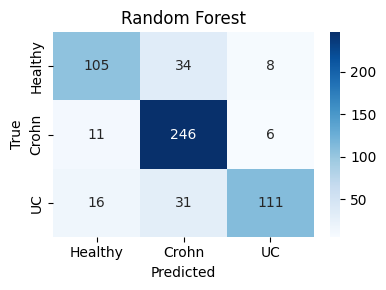

Random Forest
              precision    recall  f1-score   support

     Healthy       0.80      0.71      0.75       147
       Crohn       0.79      0.94      0.86       263
          UC       0.89      0.70      0.78       158

    accuracy                           0.81       568
   macro avg       0.82      0.78      0.80       568
weighted avg       0.82      0.81      0.81       568



In [42]:
# Random Forest confusion matrix on shared test split
y_pred_rf = rf.predict(X_test).to_numpy()
plot_cm(y_test_pd, y_pred_rf, "Random Forest")

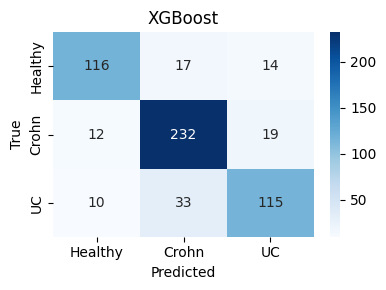

XGBoost
              precision    recall  f1-score   support

     Healthy       0.84      0.79      0.81       147
       Crohn       0.82      0.88      0.85       263
          UC       0.78      0.73      0.75       158

    accuracy                           0.82       568
   macro avg       0.81      0.80      0.81       568
weighted avg       0.81      0.82      0.81       568



In [43]:
y_proba_xgb = bst.predict(dtest)
y_pred_xgb = np.argmax(y_proba_xgb, axis=1)
plot_cm(y_test_pd, y_pred_xgb, "XGBoost")

# 8) Binary Classification: Crohn Disease vs Ulcerative Colitis

Filter to IBD samples only and train binary classifiers (Random Forest and XGBoost). All models use the IBD subset extracted in Section 3's shared split.

In [44]:
# Create IBD-only feature splits (Crohn vs UC, no Healthy)
ibd_train_mask = (y_train_pd == 0) | (y_train_pd == 1)
ibd_test_mask  = (y_test_pd  == 0) | (y_test_pd  == 1)

X_train_ibd = X_train[ibd_train_mask]
X_test_ibd  = X_test[ ibd_test_mask]
y_train_ibd = y_train_pd[ibd_train_mask]
y_test_ibd  = y_test_pd[ ibd_test_mask]

In [45]:
# Binary Model: Crohn vs UC (no Healthy) using the shared split from Section 3
print("IBD train distribution (0=Crohn, 1=UC):")
print(pd.Series(y_train_ibd).value_counts().sort_index())
print("\nIBD test distribution (0=Crohn, 1=UC):")
print(pd.Series(y_test_ibd).value_counts().sort_index())

print(f"\nTrain: {len(X_train_ibd)} samples")
print(f"Test:  {len(X_test_ibd)} samples")

IBD train distribution (0=Crohn, 1=UC):
0     586
1    1051
Name: count, dtype: int64

IBD test distribution (0=Crohn, 1=UC):
0    147
1    263
Name: count, dtype: int64

Train: 1637 samples
Test:  410 samples


In [46]:
# Step 1: XGBoost binary

dtrain_ibd = xgb.DMatrix(X_train_ibd, label=y_train_ibd)
dtest_ibd  = xgb.DMatrix(X_test_ibd,  label=y_test_ibd)

params_binary = {
    "objective": "binary:logistic",   # binary now, not multi:softprob
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "auc",             # AUC is best metric for binary
}

bst_ibd = xgb.train(
    params_binary,
    dtrain_ibd,
    num_boost_round=500,
    evals=[(dtrain_ibd, "train"), (dtest_ibd, "test")],
    early_stopping_rounds=30,
    verbose_eval=50,
)

[0]	train-auc:0.90174	test-auc:0.80745
[50]	train-auc:0.98745	test-auc:0.92791
[100]	train-auc:0.99703	test-auc:0.94434
[150]	train-auc:0.99919	test-auc:0.94990
[200]	train-auc:0.99976	test-auc:0.95155
[250]	train-auc:0.99990	test-auc:0.95287
[300]	train-auc:0.99996	test-auc:0.95424
[325]	train-auc:0.99997	test-auc:0.95393


XGBoost — Crohn vs UC
              precision    recall  f1-score   support

       Crohn       0.90      0.83      0.86       147
          UC       0.91      0.95      0.93       263

    accuracy                           0.90       410
   macro avg       0.90      0.89      0.89       410
weighted avg       0.90      0.90      0.90       410

ROC-AUC: 0.9539


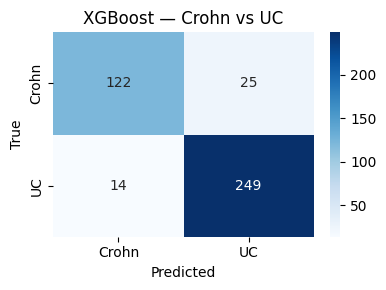

In [47]:
# Step 2: Evaluate XGBoost binary
y_proba_ibd = bst_ibd.predict(dtest_ibd)
y_pred_ibd  = (y_proba_ibd > 0.5).astype(int)

print("XGBoost — Crohn vs UC")
print(classification_report(y_test_ibd, y_pred_ibd, target_names=["Crohn", "UC"]))
print(f"ROC-AUC: {roc_auc_score(y_test_ibd, y_proba_ibd):.4f}")

# Use a separate plot function for binary — don't use plot_cm

def plot_cm_binary(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Crohn", "UC"],
                yticklabels=["Crohn", "UC"],
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cm_binary(y_test_ibd, y_pred_ibd, "XGBoost — Crohn vs UC")

Random Forest — Crohn vs UC
              precision    recall  f1-score   support

       Crohn       0.88      0.76      0.81       147
          UC       0.87      0.94      0.91       263

    accuracy                           0.88       410
   macro avg       0.88      0.85      0.86       410
weighted avg       0.88      0.88      0.87       410



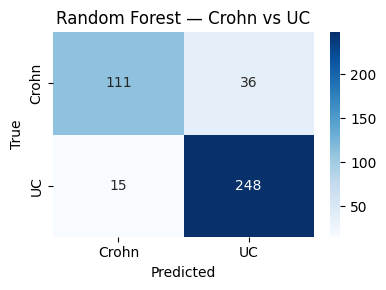

In [48]:
# Step 3: Random Forest binary
rf_ibd = cuRF(
    n_estimators=300,
    max_depth=20,
    max_features=1.0,
    n_bins=16,
    bootstrap=True,
    random_state=42,
)

X_train_ibd_gpu = cudf.DataFrame(X_train_ibd, columns=feature_cols)
X_test_ibd_gpu  = cudf.DataFrame(X_test_ibd,  columns=feature_cols)
y_train_ibd_gpu = cudf.Series(y_train_ibd)
y_test_ibd_gpu  = cudf.Series(y_test_ibd)

rf_ibd.fit(X_train_ibd_gpu, y_train_ibd_gpu)
y_pred_rf_ibd = rf_ibd.predict(X_test_ibd_gpu)

print("Random Forest — Crohn vs UC")
print(classification_report(y_test_ibd, y_pred_rf_ibd.to_numpy(), target_names=["Crohn", "UC"]))

plot_cm_binary(y_test_ibd, y_pred_rf_ibd.to_numpy(), "Random Forest — Crohn vs UC")

Default threshold (0.5): F1 = 0.9274
Optimal threshold (0.62): F1 = 0.9306

Tuned threshold results:
              precision    recall  f1-score   support

       Crohn       0.89      0.85      0.87       147
          UC       0.92      0.94      0.93       263

    accuracy                           0.91       410
   macro avg       0.90      0.89      0.90       410
weighted avg       0.91      0.91      0.91       410



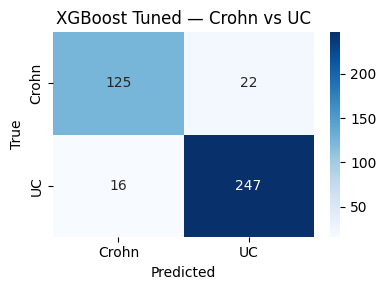

In [49]:
# Step 4: Threshold tuning — find optimal cutoff for UC recall
precisions, recalls, thresholds = precision_recall_curve(y_test_ibd, y_proba_ibd)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh = thresholds[f1_scores.argmax()]

print(f"Default threshold (0.5): F1 = {f1_score(y_test_ibd, (y_proba_ibd > 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}): F1 = {f1_scores.max():.4f}")

# Apply optimal threshold
y_pred_tuned = (y_proba_ibd > best_thresh).astype(int)
print("\nTuned threshold results:")
print(classification_report(y_test_ibd, y_pred_tuned, target_names=["Crohn", "UC"]))
plot_cm_binary(y_test_ibd, y_pred_tuned, "XGBoost Tuned — Crohn vs UC")

In [50]:
import joblib
import json

joblib.dump(bst_ibd, "bst_ibd.pkl")

with open("selected_taxa.json", "w") as f:
    json.dump(list(selected_taxa_union), f)

with open("selected_taxa.json") as f:
    features = json.load(f)

# Generate 3 fake patient samples (random microbiome abundances)
np.random.seed(42)
samples = []
for i in range(3):
    vals = np.random.dirichlet(np.ones(len(features))).tolist()
    samples.append({"features": vals, "label": ["CD", "UC", "CD"][i]})

with open("test_samples.json", "w") as f:
    json.dump(samples, f, indent=2)

print("Done! test_samples.json created with", len(features), "features per sample")

Done! test_samples.json created with 662 features per sample


In [51]:
from google.colab import files
files.download("bst_ibd.pkl")
files.download("selected_taxa.json")
files.download("test_samples.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>